/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


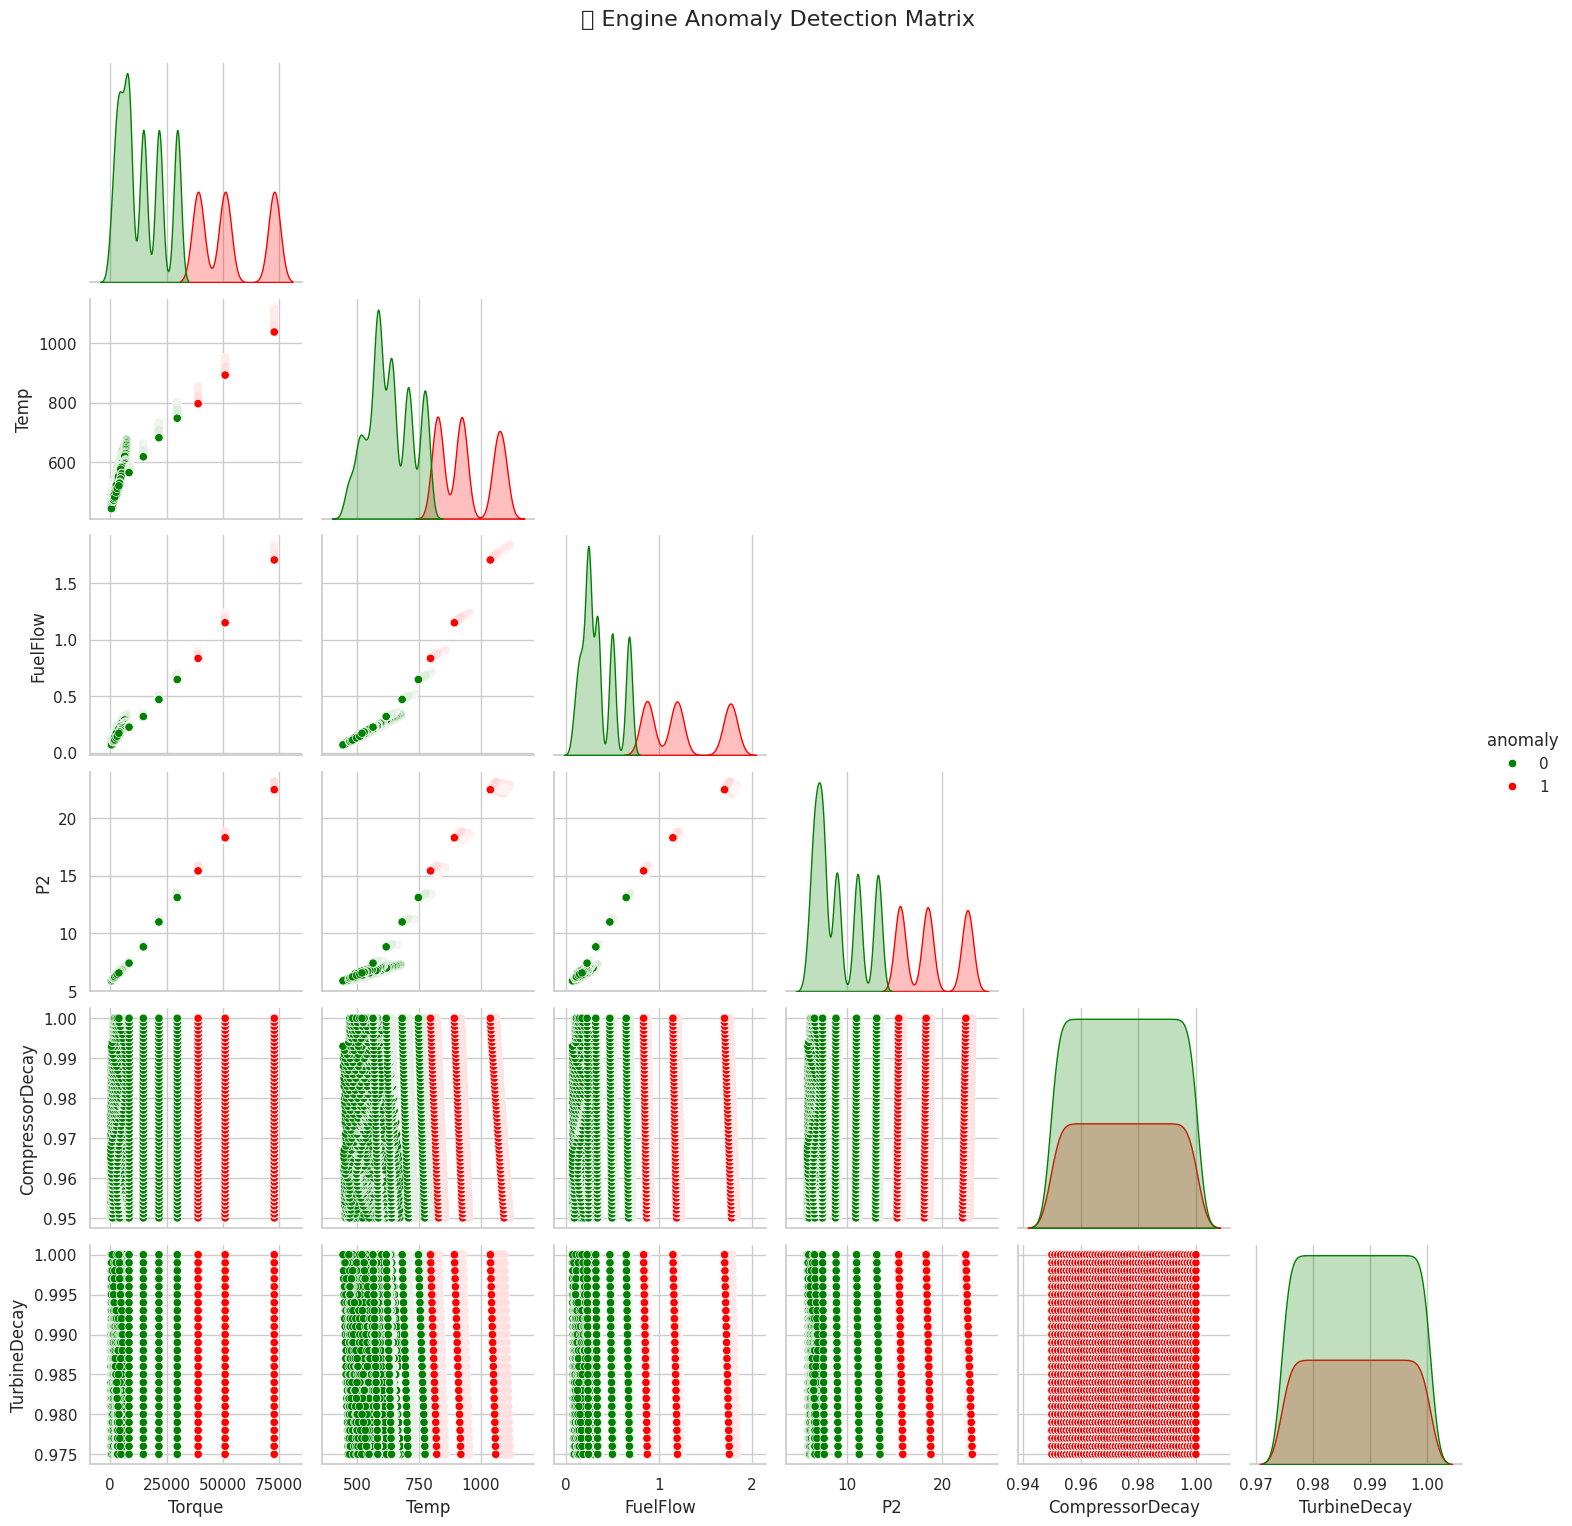

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("/content/data 2.csv")

# Clean column names by stripping spaces and non-breaking characters
df.columns = df.columns.str.strip().str.replace('\xa0', '', regex=False)

# Define anomaly conditions
df['anomaly'] = 0

df.loc[df['Gas Turbine (GT) shaft torque (GTT) [kN m]'] > 40000, 'anomaly'] = 1
df.loc[df['Hight Pressure (HP) Turbine exit temperature (T48) [C]'] > 850, 'anomaly'] = 1
df.loc[(df['Fuel flow (mf) [kg/s]'] > 1.5) | (df['Fuel flow (mf) [kg/s]'] < 0.05), 'anomaly'] = 1
df.loc[df['GT Compressor outlet air pressure (P2) [bar]'] > 15, 'anomaly'] = 1
df.loc[df['GT Turbine decay state coefficient'] < 0.85, 'anomaly'] = 1
df.loc[df['GT Compressor decay state coefficient'] < 0.85, 'anomaly'] = 1

# Select and rename important columns for visualization
selected = df[[
    'Gas Turbine (GT) shaft torque (GTT) [kN m]',
    'Hight Pressure (HP) Turbine exit temperature (T48) [C]',
    'Fuel flow (mf) [kg/s]',
    'GT Compressor outlet air pressure (P2) [bar]',
    'GT Compressor decay state coefficient',
    'GT Turbine decay state coefficient',
    'anomaly'
]]

selected.columns = ['Torque', 'Temp', 'FuelFlow', 'P2', 'CompressorDecay', 'TurbineDecay', 'anomaly']

# Plot the pairplot
sns.set(style="whitegrid")
plot = sns.pairplot(selected, hue="anomaly", palette={0: "green", 1: "red"}, corner=True)
plot.fig.suptitle("🚨 Engine Anomaly Detection Matrix", y=1.02, fontsize=16)
plt.show()


Magnetic

In [ ]:
!pip install plotly

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Load the magnetic data
df = pd.read_csv("Magnetic_Declinations.csv")
df.columns = df.columns.str.strip()

# Define anomalies
df['anomaly'] = 0
df.loc[(df['Declination'] > 30) | (df['Declination'] < -30), 'anomaly'] = 1
df = df.sort_values(by=['Lat', 'Lon', 'Year'])
df['delta_decl'] = df.groupby(['Lat', 'Lon'])['Declination'].diff()
df['anomaly'] = np.where(df['delta_decl'].abs() > 5, 1, df['anomaly'])

# Arrow direction vectors
df['dx'] = np.cos(np.radians(df['Declination']))
df['dy'] = np.sin(np.radians(df['Declination']))

# Reduce density for animation
df_anim = df[df['Year'] % 10 == 0].copy()
arrow_scale = 5
df_anim['end_lat'] = df_anim['Lat'] + df_anim['dy'] / arrow_scale
df_anim['end_lon'] = df_anim['Lon'] + df_anim['dx'] / arrow_scale

# Convert to lines
lines = []
for _, row in df_anim.iterrows():
    lines.append({
        'Year': row['Year'],
        'Lat': row['Lat'],
        'Lon': row['Lon'],
        'Lat_end': row['end_lat'],
        'Lon_end': row['end_lon'],
        'Anomaly': 'Anomaly' if row['anomaly'] else 'Normal'
    })
line_df = pd.DataFrame(lines)

# Animate frames
years = sorted(line_df['Year'].unique())
frames = []
for year in years:
    d = line_df[line_df['Year'] == year]
    frames.append(go.Frame(
        data=[go.Scattergeo(
            lon=np.ravel([[x, y, None] for x, y in zip(d['Lon'], d['Lon_end'])]),
            lat=np.ravel([[x, y, None] for x, y in zip(d['Lat'], d['Lat_end'])]),
            mode='lines',
            line=dict(width=1.5, color='red')
        )],
        name=str(year)
    ))

# Base figure
initial = line_df[line_df['Year'] == years[0]]
fig = go.Figure(
    data=[go.Scattergeo(
        lon=np.ravel([[x, y, None] for x, y in zip(initial['Lon'], initial['Lon_end'])]),
        lat=np.ravel([[x, y, None] for x, y in zip(initial['Lat'], initial['Lat_end'])]),
        mode='lines',
        line=dict(width=1.5, color='red')
    )],
    layout=go.Layout(
        title="🧲 Magnetic Declination Vector Animation (1750–2020)",
        geo=dict(
            scope='world',
            projection_type='natural earth',
            showland=True,
            landcolor='rgb(217, 217, 217)',
        ),
        updatemenus=[{
            'type': 'buttons',
            'buttons': [{
                'label': '▶️ Play',
                'method': 'animate',
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}]
            }]
        }]
    ),
    frames=frames
)

fig.show()


Weather

In [ ]:
import pandas as pd
import plotly.express as px

# Load and clean
df = pd.read_csv("Weather.csv")
df.columns = df.columns.str.strip()
df['Description'] = df['Description'].fillna('?').astype(str).str.strip()
df['Symbol'] = df['Symbol'].astype(str).str.replace('#', '').str.replace('.jpg', '')

# Flag anomalies
df['Anomaly'] = df['Description'].apply(lambda x: '⚠️ Missing' if x == '?' else '✅ Defined')

# Sunburst hierarchical structure: Anomaly -> Description -> Symbol
fig = px.sunburst(
    df,
    path=['Anomaly', 'Description', 'Symbol'],
    values=None,
    color='Anomaly',
    color_discrete_map={'⚠️ Missing': 'red', '✅ Defined': 'green'},
    title='🌤️ Weather Symbol and Description Classification Map'
)

fig.update_traces(textinfo='label+percent parent')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("Weather.csv")
df.columns = df.columns.str.strip()
df['Description'] = df['Description'].fillna('?').astype(str).str.strip()
df['Symbol'] = df['Symbol'].astype(str).str.replace('#', '').str.replace('.jpg', '')

# Manual Dutch-to-English dictionary
translation_dict = {
    'Lichte buien': 'Light showers',
    'Buien. Matige buien': 'Moderate showers',
    'Zware buien': 'Heavy showers',
    'Toenemende buien': 'Increasing showers',
    'Buien rondom': 'Showers around',
    'Afnemende buien': 'Decreasing showers',
    'Mistig': 'Foggy',
    'Dik van de mist': 'Thick fog',
    '?': '⚠️ Unknown'
}

# Apply translation
df['English_Desc'] = df['Description'].apply(lambda x: translation_dict.get(x, x))

# Flag anomaly
df['Anomaly'] = df['Description'].apply(lambda x: '⚠️ Anomaly Detected' if x == '?' else '✅ Normal')

# Plot sunburst: [Anomaly] → [English Desc] → [Symbol]
fig = px.sunburst(
    df,
    path=['Anomaly', 'English_Desc', 'Symbol'],
    color='Anomaly',
    color_discrete_map={
        '⚠️ Anomaly Detected': 'red',
        '✅ Normal': 'green'
    },
    title='🌦️ Weather Symbol Categorization + Anomaly Alert View',
    height=700
)

fig.update_traces(textinfo='label+percent parent')
fig.show()
